<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter2/exact_vs_small_angle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparison of angle $\theta(t)$ exact solution with the small angle approximation



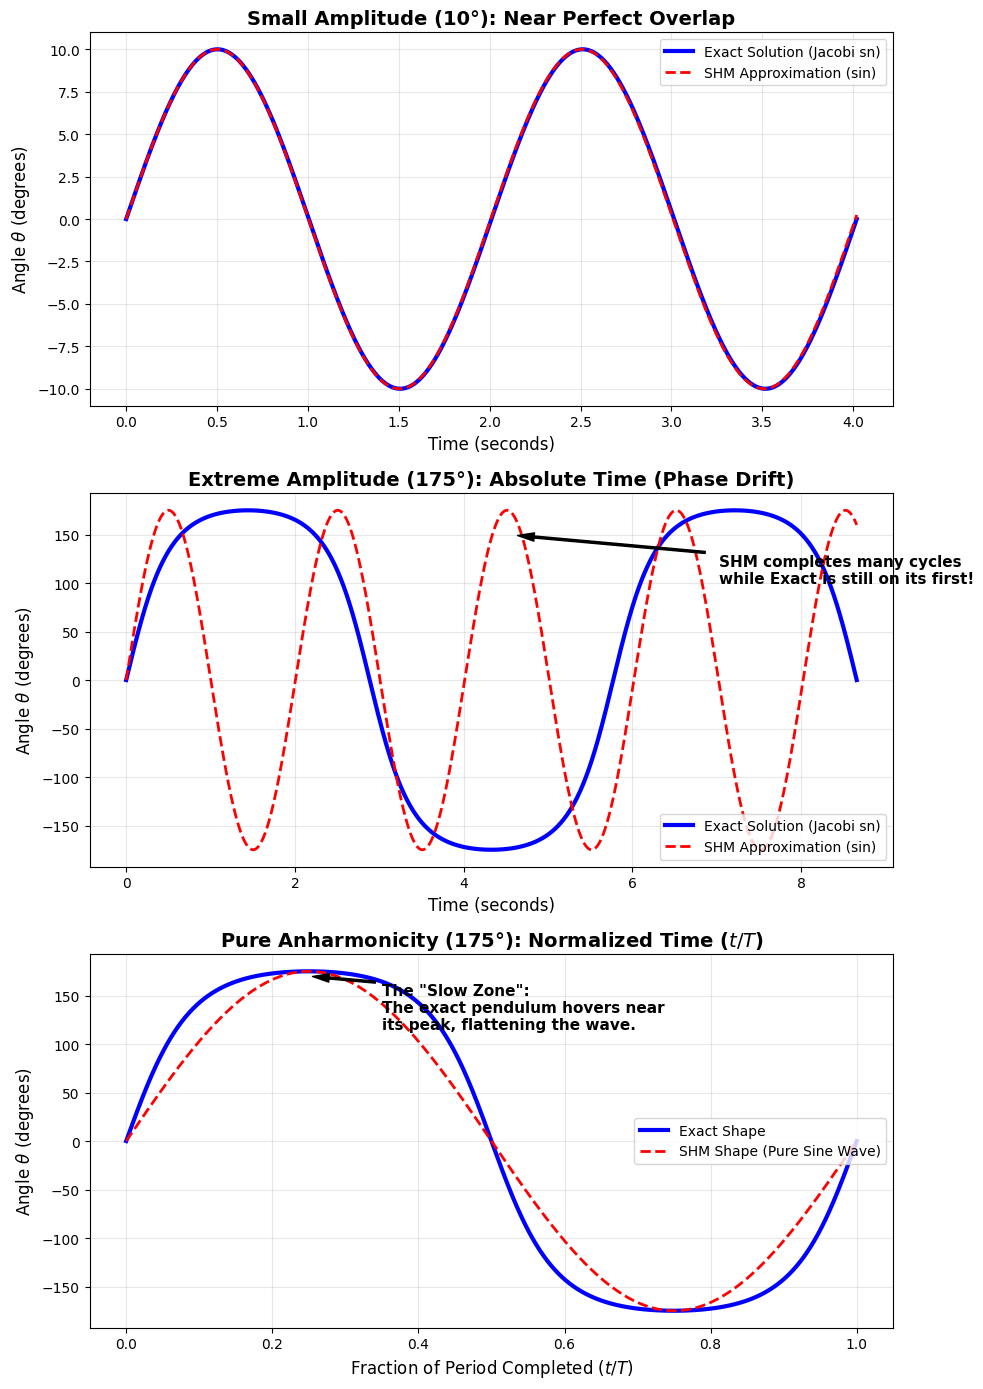

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipj, ellipk

def calculate_trajectories(theta_0_deg, num_cycles=1.0, l=1.0, g=9.81):
    """
    Calculates exact and SHM trajectories. Starts from the bottom (theta=0)
    and swings up to theta_0 to match the arcsin(sn) formula.
    """
    theta_0 = np.radians(theta_0_deg)
    omega = np.sqrt(g / l)

    # Calculate the exact nonlinear period using the Complete Elliptic Integral K
    m = np.sin(theta_0 / 2.0)**2
    K = ellipk(m)

    T_shm = 2 * np.pi / omega
    T_exact = 4 * K / omega

    # Generate time array covering the requested number of EXACT cycles
    t = np.linspace(0, num_cycles * T_exact, 2000)

    # 1. Calculate Simple Harmonic Motion (SHM)
    theta_shm = theta_0 * np.sin(omega * t)

    # 2. Calculate Exact Nonlinear Solution
    sn_vals, _, _, _ = ellipj(omega * t, m)
    theta_exact = 2 * np.arcsin(np.sin(theta_0 / 2.0) * sn_vals)

    return t, np.degrees(theta_exact), np.degrees(theta_shm), T_exact, T_shm

# ==========================================
# Plotting Comparison
# ==========================================
if __name__ == "__main__":
    # Create 3 subplots instead of 2, and increase the height of the figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))

    # ------------------------------------------
    # Subplot 1: Small Angle (10 degrees) - Perfect Match
    # ------------------------------------------
    test_angle_small = 10
    t_sm, exact_th_sm, shm_th_sm, T_ex_sm, T_shm_sm = calculate_trajectories(test_angle_small, num_cycles=2.0)

    ax1.plot(t_sm, exact_th_sm, 'b-', linewidth=3, label='Exact Solution (Jacobi sn)')
    ax1.plot(t_sm, shm_th_sm, 'r--', linewidth=2, label='SHM Approximation (sin)')

    ax1.set_title(f'Small Amplitude ({test_angle_small}°): Near Perfect Overlap', fontsize=14, weight='bold')
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel('Angle $\\theta$ (degrees)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # We will use an extreme angle to highlight the anharmonicity for the next plots
    test_angle = 175

    t, exact_th, shm_th, T_exact, T_shm = calculate_trajectories(test_angle, num_cycles=1.5)

    # ------------------------------------------
    # Subplot 2: Absolute Time (Highlights Phase Drift)
    # ------------------------------------------
    ax2.plot(t, exact_th, 'b-', linewidth=3, label='Exact Solution (Jacobi sn)')
    ax2.plot(t, shm_th, 'r--', linewidth=2, label='SHM Approximation (sin)')

    # Annotate the phase drift
    ax2.annotate(f'SHM completes many cycles\nwhile Exact is still on its first!',
                 xy=(T_shm * 2.25, 150), xytext=(T_shm * 3.5, 100),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, weight='bold')

    ax2.set_title(f'Extreme Amplitude ({test_angle}°): Absolute Time (Phase Drift)', fontsize=14, weight='bold')
    ax2.set_xlabel('Time (seconds)', fontsize=12)
    ax2.set_ylabel('Angle $\\theta$ (degrees)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower right')

    # ------------------------------------------
    # Subplot 3: Normalized Time (Highlights Shape/Anharmonicity)
    # ------------------------------------------
    # We create a generic "phase" array from 0 to 1 (representing 1 full period)
    phase = np.linspace(0, 1, 1000)

    # SHM mapped to 1 period
    norm_shm = test_angle * np.sin(2 * np.pi * phase)

    # Exact mapped to 1 period (omega * t = 4 * K * phase)
    m_ext = np.sin(np.radians(test_angle) / 2.0)**2
    K_ext = ellipk(m_ext)
    sn_vals_norm, _, _, _ = ellipj(4 * K_ext * phase, m_ext)
    norm_exact = np.degrees(2 * np.arcsin(np.sin(np.radians(test_angle)/2) * sn_vals_norm))

    ax3.plot(phase, norm_exact, 'b-', linewidth=3, label='Exact Shape')
    ax3.plot(phase, norm_shm, 'r--', linewidth=2, label='SHM Shape (Pure Sine Wave)')

    # Annotate the anharmonicity
    ax3.annotate('The "Slow Zone":\nThe exact pendulum hovers near\nits peak, flattening the wave.',
                 xy=(0.25, test_angle - 5), xytext=(0.35, test_angle - 60),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, weight='bold')

    ax3.set_title(f'Pure Anharmonicity ({test_angle}°): Normalized Time ($t / T$)', fontsize=14, weight='bold')
    ax3.set_xlabel('Fraction of Period Completed ($t / T$)', fontsize=12)
    ax3.set_ylabel('Angle $\\theta$ (degrees)', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='center right')

    plt.tight_layout()
    plt.show()